# Pixel Art SDXL LoRA (A100 <20h)

End-to-end pipeline: auto-download -> ingest -> clean -> caption -> train -> eval.

In [1]:
  !git clone https://github.com/arifdag/Text-to-Image-Pixel-Art.git
  %cd /content/Text-to-Image-Pixel-Art
  !git pull origin main
  !ls

Cloning into 'Text-to-Image-Pixel-Art'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 60 (delta 17), reused 53 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 39.50 KiB | 13.17 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/Text-to-Image-Pixel-Art
From https://github.com/arifdag/Text-to-Image-Pixel-Art
 * branch            main       -> FETCH_HEAD
Already up to date.
AGENTS.md  data		    pyproject.toml  requirements-dev.txt  tests
artifacts  DATA_SOURCES.md  README.md	    requirements.txt
configs    notebooks	    Report.md	    src


In [2]:
!nvidia-smi
import torch
print('CUDA:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Sat Feb 21 13:56:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             46W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
!pip install -q -U pip
!pip install -q --upgrade torch==2.10.0 torchvision==0.25.0 torchaudio==2.10.0 --index-url https://download.pytorch.org/whl/cu128
!pip install -q -r requirements.txt -r requirements-dev.txt
!pip install -q -U datasets pyyaml "pillow<12"
!pip install -q -e .

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 75.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for pixelart-generator (pyproject.toml) ... done


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Optional: Clone Diffusers Examples
Required for the SDXL LoRA training script path in `configs/train_sdxl_lora.yaml`.

In [5]:
!git clone https://github.com/huggingface/diffusers.git /content/diffusers

Cloning into '/content/diffusers'...
remote: Enumerating objects: 117069, done.
remote: Counting objects: 100% (1078/1078), done.
remote: Compressing objects: 100% (609/609), done.
remote: Total 117069 (delta 750), reused 469 (delta 469), pack-reused 115991 (from 4)
Receiving objects: 100% (117069/117069), 92.07 MiB | 19.79 MiB/s, done.
Resolving deltas: 100% (87132/87132), done.


## Step 1: Auto-download datasets and generate `configs/data_sources.yaml`

This also creates caption sidecars so you do not manually write prompts.

In [6]:
from datasets import load_dataset
from pathlib import Path
import json
import os
import yaml

if Path('configs').exists():
    ROOT = Path('.').resolve()
elif Path('../configs').exists():
    ROOT = Path('..').resolve()
else:
    raise RuntimeError('Run this notebook from repo root or from notebooks/.')

os.chdir(ROOT)
DATA_ROOT = Path('/content/data')
DATA_ROOT.mkdir(parents=True, exist_ok=True)
(ROOT / 'configs').mkdir(parents=True, exist_ok=True)

def pick_col(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

def export_hf_dataset(dataset_id, source_id, max_items, license_name, attribution, notes):
    ds = load_dataset(dataset_id, split='train')
    cols = ds.column_names
    image_col = pick_col(cols, ['image', 'img', 'pixel_art', 'pixelart'])
    text_col = pick_col(cols, ['prompt', 'text', 'caption', 'description'])

    if image_col is None:
        raise RuntimeError(f'{dataset_id}: no image column found. columns={cols}')

    img_dir = DATA_ROOT / source_id / 'images'
    cap_path = DATA_ROOT / source_id / 'captions.jsonl'
    img_dir.mkdir(parents=True, exist_ok=True)

    n = 0
    with cap_path.open('w', encoding='utf-8') as fout:
        for row in ds:
            if max_items and n >= max_items:
                break
            img = row[image_col]
            if img is None:
                continue
            file_name = f'{n:06d}.png'
            img.save(img_dir / file_name)
            text = ''
            if text_col and row.get(text_col) is not None:
                text = str(row[text_col]).strip()
            fout.write(json.dumps({'file_name': file_name, 'text': text}, ensure_ascii=True) + '\n')
            n += 1

    return {
        'id': source_id,
        'local_path': str(img_dir),
        'captions_path': str(cap_path),
        'captions_key_field': 'file_name',
        'captions_text_field': 'text',
        'license': license_name,
        'attribution': attribution,
        'notes': notes,
        'max_files': n,
    }, n

sources = []

s1, n1 = export_hf_dataset(
    dataset_id='nerijs/pixelparti-128-v0.1',
    source_id='pixelparti_seed',
    max_items=3000,
    license_name='CC0-1.0',
    attribution='nerijs/pixelparti-128-v0.1',
    notes='Synthetic prompt-paired pixel-art starter dataset.'
)
sources.append(s1)
print('pixelparti_seed:', n1)

try:
    s2, n2 = export_hf_dataset(
        dataset_id='Limbicnation/pixel-art-character',
        source_id='pixel_character',
        max_items=2000,
        license_name='Apache-2.0',
        attribution='Limbicnation/pixel-art-character',
        notes='Character sprite dataset.'
    )
    sources.append(s2)
    print('pixel_character:', n2)
except Exception as e:
    print('Skipping optional source 2:', e)

cfg = {'sources': sources}
cfg_path = ROOT / 'configs' / 'data_sources.yaml'
cfg_path.write_text(yaml.safe_dump(cfg, sort_keys=False, allow_unicode=False), encoding='utf-8')
print('Wrote:', cfg_path)
print(cfg_path.read_text(encoding='utf-8'))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4836 [00:00<?, ? examples/s]

pixelparti_seed: 3000


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/58.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/500 [00:00<?, ? examples/s]

pixel_character: 500
Wrote: /content/Text-to-Image-Pixel-Art/configs/data_sources.yaml
sources:
- id: pixelparti_seed
  local_path: /content/data/pixelparti_seed/images
  captions_path: /content/data/pixelparti_seed/captions.jsonl
  captions_key_field: file_name
  captions_text_field: text
  license: CC0-1.0
  attribution: nerijs/pixelparti-128-v0.1
  notes: Synthetic prompt-paired pixel-art starter dataset.
  max_files: 3000
- id: pixel_character
  local_path: /content/data/pixel_character/images
  captions_path: /content/data/pixel_character/captions.jsonl
  captions_key_field: file_name
  captions_text_field: text
  license: Apache-2.0
  attribution: Limbicnation/pixel-art-character
  notes: Character sprite dataset.
  max_files: 500



## Step 2: Ingest, clean, and caption metadata

Captions from the downloaded sidecars are used automatically.

In [7]:
!python -m pixelart.data_ingest --config configs/data_sources.yaml --output-dir data/raw --index-out data/raw/index.jsonl
!python -m pixelart.data_clean --input-dir data/raw --index-in data/raw/index.jsonl --output-dir data/clean/images --index-out data/clean/index.jsonl
!python -m pixelart.caption --index-in data/clean/index.jsonl --output-dir data/train --metadata-out data/train/metadata.jsonl --prefer-source-prompt

Ingested 3500 files to data/raw
Index: data/raw/index.jsonl
Registry: DATA_SOURCES.md
Kept 2373 images
Rejected 1127 images
Clean index: data/clean/index.jsonl
Wrote 2373 caption rows to data/train/metadata.jsonl


## Optional: Fill missing prompts with BLIP-2 captions

In [8]:
!python -m pixelart.caption --index-in data/clean/index.jsonl --output-dir data/train --metadata-out data/train/metadata.jsonl --prefer-source-prompt --use-blip

processor_config.json: 100% 68.0/68.0 [00:00<00:00, 302kB/s]
preprocessor_config.json: 100% 432/432 [00:00<00:00, 3.05MB/s]
The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
config.json: 1.03kB [00:00, 3.19MB/s]
tokenizer_config.json: 100% 882/882 [00:00<00:00, 4.54MB/s]
vocab.json: 798kB [00:00, 84.0MB/s]
merges.txt: 456kB [00:00, 106MB/s]
added_tokens.json: 100% 23.0/23.0 [00:00<00:00, 121kB/s]
special_tokens_map.json: 100% 548/548 [00:00<00:00, 2.95MB/s]
tokenizer.json: 3.56MB [00:00, 189MB/s]
model.safetensors.index.json: 122kB [00:00, 198MB/s]
Fetching 2 files: 100% 2/2 [00:38<00:00, 19.40s/it]
Download complete: 100% 15.0G/15.0G [00:38<00:00, 385MB/s]
Loading weights: 100% 1247/1247 [00:02<00:00, 479.47it/s, Materializing 

In [9]:
  %cd /content/Text-to-Image-Pixel-Art
  !git pull origin main

  !rm -rf /content/diffusers
  !git clone https://github.com/huggingface/diffusers.git /content/diffusers
  !pip uninstall -y diffusers
  !pip install -q -e /content/diffusers

/content/Text-to-Image-Pixel-Art
From https://github.com/arifdag/Text-to-Image-Pixel-Art
 * branch            main       -> FETCH_HEAD
Already up to date.
Cloning into '/content/diffusers'...
remote: Enumerating objects: 117069, done.
remote: Counting objects: 100% (1078/1078), done.
remote: Compressing objects: 100% (609/609), done.
remote: Total 117069 (delta 750), reused 469 (delta 469), pack-reused 115991 (from 4)
Receiving objects: 100% (117069/117069), 92.07 MiB | 15.59 MiB/s, done.
Resolving deltas: 100% (87132/87132), done.
Found existing installation: diffusers 0.36.0
Uninstalling diffusers-0.36.0:
  Successfully uninstalled diffusers-0.36.0
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for diffusers (pyproject.toml) ... done


## Step 3: Train LoRA
The config uses `resume_from_checkpoint: latest`.

In [ ]:
!python -m pixelart.train --config configs/train_sdxl_lora.yaml

Training command:
accelerate launch /content/diffusers/examples/text_to_image/train_text_to_image_lora_sdxl.py --pretrained_model_name_or_path stabilityai/stable-diffusion-xl-base-1.0 --pretrained_vae_model_name_or_path madebyollin/sdxl-vae-fp16-fix --train_data_dir /content/Text-to-Image-Pixel-Art/data/train --output_dir /content/drive/MyDrive/pixelart-lora-output --resolution 1024 --image_interpolation_mode nearest --train_batch_size 4 --gradient_accumulation_steps 4 --learning_rate 0.0001 --max_train_steps 8000 --checkpointing_steps 500 --checkpoints_total_limit 5 --rank 16 --seed 42 --snr_gamma 5.0 --validation_prompt pixel art, female knight with blue cape, full body sprite, simple background --validation_epochs 1 --mixed_precision bf16 --lr_scheduler constant --lr_warmup_steps 0 --num_validation_images 4 --dataloader_num_workers 8 --max_grad_norm 1.0 --allow_tf32
Manifest: /content/drive/MyDrive/pixelart-lora-output/run_manifest.json
The following values were not passed to `accel

## Step 4: Evaluate baseline vs LoRA

In [10]:
import os, yaml, subprocess, sys
from pathlib import Path

repo = Path("/content/Text-to-Image-Pixel-Art")
os.chdir(repo)

# Drive checkpoint settings
CHECKPOINT = "checkpoint-8000"
LORA_SCALE = 0.65
LORA_ROOT = Path("/content/drive/MyDrive/pixelart-lora-output")
PROMPTS_FILE = repo / "configs" / "prompts_v2.json"
if not PROMPTS_FILE.exists():
    fallback = repo / "configs" / "prompts_v1.json"
    if fallback.exists():
        print(f"prompts_v2.json not found, using fallback: {fallback}")
        PROMPTS_FILE = fallback

if not LORA_ROOT.exists():
    raise FileNotFoundError(f"Missing LoRA root: {LORA_ROOT}")
if not (LORA_ROOT / CHECKPOINT).exists():
    raise FileNotFoundError(f"Missing checkpoint dir: {LORA_ROOT / CHECKPOINT}")
if not PROMPTS_FILE.exists():
    raise FileNotFoundError(
        f"Missing prompts file: {PROMPTS_FILE}; available: {sorted((repo / 'configs').glob('prompts*.json'))}"
    )

cfg = yaml.safe_load(Path("configs/eval.yaml").read_text())
cfg["lora_path"] = str(LORA_ROOT)
cfg["checkpoint_subdir"] = CHECKPOINT
cfg["lora_scale"] = float(LORA_SCALE)
cfg["prompts_file"] = str(PROMPTS_FILE)
cfg["eval_mode"] = "memory_safe"  # safer on Colab GPUs
cfg["output_dir"] = f"artifacts/eval_{CHECKPOINT}_s{str(LORA_SCALE).replace('.', '')}"

cfg_path = Path("configs") / f"eval_{CHECKPOINT}_s{str(LORA_SCALE).replace('.', '')}.yaml"
cfg_path.write_text(yaml.safe_dump(cfg, sort_keys=False))

print("Running:", cfg_path)
result = subprocess.run(
    [sys.executable, "-m", "pixelart.eval", "--config", str(cfg_path)],
    text=True,
    capture_output=True,
)
if result.stdout:
    print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(f"Eval failed with exit code {result.returncode}")


Running: configs/eval_checkpoint-8000_s065.yaml


CalledProcessError: Command '['/usr/bin/python3', '-m', 'pixelart.eval', '--config', 'configs/eval_checkpoint-8000_s065.yaml']' returned non-zero exit status 1.

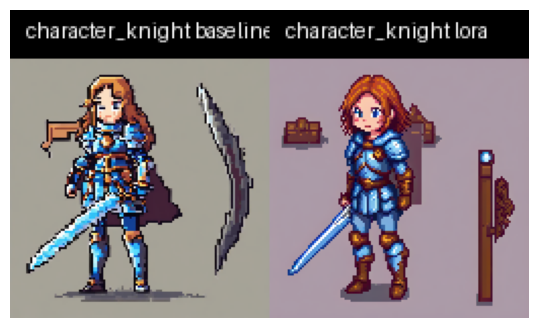

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

grid_files = sorted(Path('artifacts/eval/grids').glob('*.png'))
if grid_files:
    img = Image.open(grid_files[0])
    plt.figure(figsize=(12, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print('No grids found yet.')